In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable

## 3.신경망과 활성화 함수
+ 활성화함수는 신호의 총합이 다음 층으로 전달될지 여부를 결정한다.
    > 어떤 활성화함수를 쓰는 것이 가장 좋은가? ReLu의 미분가능성?
+ 활성화함수의 핵심은 비선형성에 있다. 선형성을 가진 활성화함수를 사용하면, 아무리 층을 깊게 하더라도 은닉층이 없는 네트워크로도 똑같은 기능을 할 수 있기에 무의미하다.

<br>

+ 퍼셉트론은 활성화함수로 계단함수를 활용한다. `>0 return 1`~~이 부분.
+ 보통 미적분같은 대수학 과목에서는 arctan, tanh, erf 등 s자 개형을 가진 함수들을 통칭하여 시그모이드 함수라고 부른다. 그러나 보통 ML/DL 분야에서는 $\sigma = \frac{1}{1+e^{-x}}$인 함수 $\sigma$만을 시그모이드 함수라고 칭한다.

<br>



In [3]:
def step_function(x):
    if x > 0:
        return 1
    else:
        return 0
    
def step_function(x):
    y = (x > 0)             ## return np.ndarray[Bool]
    return y.astype(int)

In [4]:
def show_plot(f: Callable, x_range: tuple=(-5.0, 5.0, 0.1), x_lim: tuple=(-6, 6), y_lim: tuple=(-0.1, 1.1))->None:
    x_range = np.arange(*x_range)
    y = f(x_range)
    
    plt.plot(x_range,y)
    plt.ylim(*y_lim)
    plt.xlim(*x_lim)
    plt.grid()
    plt.show()

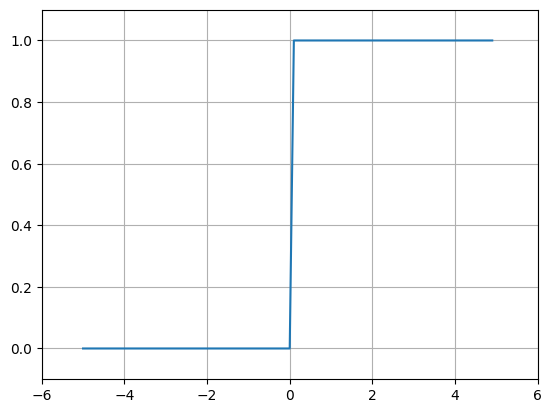

In [5]:
show_plot(step_function)

In [6]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [7]:
x = np.array([-1.0, 1.0, 2.0])
sigmoid(x)

array([0.26894142, 0.73105858, 0.88079708])

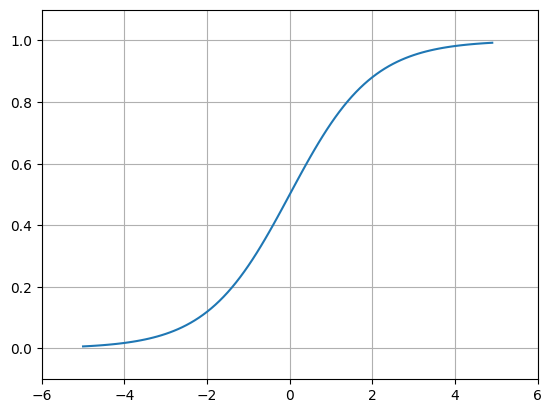

In [8]:
show_plot(sigmoid)

In [9]:
np.ndarray([1,2,3])

array([[[0.41722222, 0.33722222, 0.41722222],
        [4.03322222, 5.37722222, 0.33722222]]])

In [10]:
def relu(x: np.ndarray[int])-> np.ndarray:
    return np.maximum(0, x)

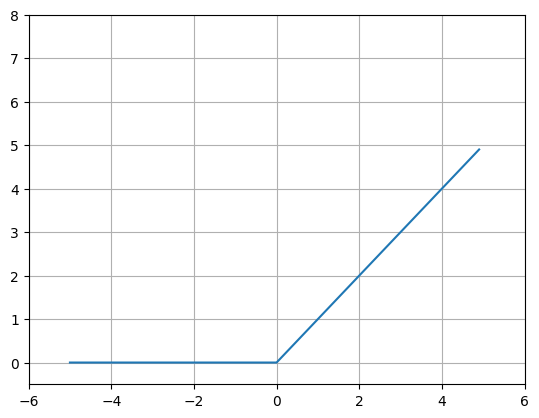

In [11]:
show_plot(relu,x_range=(-5.0, 5.0, 0.1), y_lim=(-0.5, 8))

### 다차원 행렬 계산
+ `np.dot()`은 벡터의 내적, 스칼라곱, 행렬곱 등 다양한 기능을 동시에 수행한다. 
+ 따라서 가능하면 행렬곱의 경우 `np.matmul()`이나 `@`연산자를, 스칼라곱의 경우 `np.multiply()`나 `*`연산자를 사용하는 것이 더 명시적이다!(https://jimmy-ai.tistory.com/75)

In [12]:
print(np.dot([1,2],[3,4]))  ## 1차원 행렬, 즉 벡터인 경우에는 그냥 스칼라콥
print(np.dot([[1,2],        ## 2차원 이상의 행렬인 경우에는 행렬곱
              [3,4]], [[5,6],
                       [7,8]]))

11
[[19 22]
 [43 50]]


### 3층 신경망 구현하기

In [13]:
## 0(입력층) -> 1층으로 계산
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5],
               [0.2, 0.4, 0.6]])

B1 = np.array([0.1, 0.2, 0.3])

A1 = X @ W1 + B1
print(A1)

## 활성화 함수를 거치자
Z1 = sigmoid(A1)

print(Z1)

[0.3 0.7 1.1]
[0.57444252 0.66818777 0.75026011]


In [14]:
## 1층 -> 2층으로 계산
print(Z1.shape)

W2 = np.array([[0.1, 0.4],
               [0.2, 0.5],
               [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

A2 = (Z1 @ W2) + B2
print(A2)

Z2 = sigmoid(A2)
print(Z2)

(3,)
[0.51615984 1.21402696]
[0.62624937 0.7710107 ]


In [15]:
print(Z2.shape)
W3 = np.array([[0.1, 0.3],
               [0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = (Z2 @ W3) + B3
Y = A3                  ## 여기서 출력층에서의 활성화 함수는 항등함수
print(Y)

(2,)
[0.31682708 0.69627909]


구현 정리하기

In [16]:
class Net():
    def __init__(self):
        self.network = {}
        
        self.network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
        self.network['b1'] = np.array([0.1, 0.2, 0.3])
        self.network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
        self.network['b2'] = np.array([0.1, 0.2])
        self.network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
        self.network['b3'] = np.array([0.1, 0.2])
        
    def forward(self, x):
        a1 = (x @ self.network['W1']) + self.network['b1']
        z1 = sigmoid(a1)
        
        a2 = (z1 @ self.network['W2']) + self.network['b2']
        z2 = sigmoid(a2)
        
        a3 = (z2 @ self.network['W3']) + self.network['b3']
        y = a3
        
        return y

In [17]:
net = Net()

x = np.array([1.0, 0.5])
y = net.forward(x)
print(y)

[0.31682708 0.69627909]


## 3.5.출력층 설계하기

In [18]:
def softmax(x: np.ndarray)->np.ndarray:
    return np.exp(x) / np.sum(np.exp(x))

a = np.arange(4)
np.sum(softmax(a))

1.0

In [19]:
a = np.array([1010, 1000, 900])
print(np.exp(a) / np.sum(np.exp(a)))   ## overflow!

c = np.max(a)
print(np.exp(a -c) / np.sum(np.exp(a-c)))

[nan nan nan]
[9.99954602e-01 4.53978687e-05 1.68883521e-48]


C:\Users\dieyo\AppData\Local\Temp\ipykernel_3104\300548667.py:2: RuntimeWarning: overflow encountered in exp
  print(np.exp(a) / np.sum(np.exp(a)))   ## overflow!
C:\Users\dieyo\AppData\Local\Temp\ipykernel_3104\300548667.py:2: RuntimeWarning: invalid value encountered in divide
  print(np.exp(a) / np.sum(np.exp(a)))   ## overflow!


In [20]:
def softmax(x: np.ndarray)->np.ndarray:
    return np.exp(x - np.max(x)) / np.sum(np.exp(x - np.max(x)))

softmax(a)

array([9.99954602e-01, 4.53978687e-05, 1.68883521e-48])

## 3.6.MNIST
+ flatten과 normalize의 의미?
  + flatten은 1차원 배열로 바꾼다. 즉 한줄로 쭉~!
  + normalize는 이미지를 중심에 가깝게 모아두고, stdev로 나누어 z-score 값 얻는다. 이처럼 인풋값이 비슷한 레인지로 있어야지 기울기가 발산하지 않는다.
    > We'd like in this process for each feature to have a similar range so that our gradients don't go out of control (and that we only need one global learning rate multiplier).
    Another way you can think about it is deep learning networks traditionally share many parameters - if you didn't scale your inputs in a way that resulted in similarly-ranged feature values (ie: over the whole dataset by subtracting mean) sharing wouldn't happen very easily because to one part of the image weight w is a lot and to another it's too small.
    + 단, NMIST의 경우 흑백이미지인지라 정규화를 안해도 크게 성능이 저하되지는 않는 듯?

In [21]:
import sys, os

if './official_github' not in sys.path:
    sys.path.append('./official_github')
    
from dataset.mnist import load_mnist
from PIL import Image
import pickle

In [22]:
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

print(x_train.shape, t_train.shape, x_test.shape, t_test.shape, sep = '\n')

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [23]:
def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

sample_img, sample_label = x_train[0], t_train[0]
print(sample_label)

print(sample_img.shape)
img_show(sample_img.reshape(28, 28))


5
(784,)


In [34]:
def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test

def init_network():
    with open('./official_github/ch3.신경망/sample_weight.pkl', 'rb') as f:
        network = pickle.load(f)
    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    
    z1 = sigmoid(x @ W1 + b1)
    z2 = sigmoid(z1 @ W2 + b2)
    y = softmax(z2 @ W3 + b3)
    
    return y    

In [32]:
x, t = get_data()
network = init_network()

type(network)

dict

In [33]:
acc = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    
    if p == t[i]:
        acc += 1

print(acc / len(x))

C:\Users\dieyo\AppData\Local\Temp\ipykernel_3104\4033946986.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


0.9207


### 배치 처리

In [35]:
x, t = get_data()
network = init_network()
batch_size = 100

acc = 0
for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    acc += np.sum(p == t[i:i+batch_size])
    
print(acc / len(x))
    
    

0.9352
